In [56]:
import warnings

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module="torch_geometric"
)

In [4]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import librosa

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool

from tqdm.auto import tqdm

In [5]:
PROJECT_ROOT = Path.cwd().parent
METADATA_PATH = PROJECT_ROOT / "data" / "fma_metadata" / "tracks.csv"

df = pd.read_csv(METADATA_PATH, header=[0, 1], low_memory=False)

df.shape

(106575, 53)

In [6]:
columns = pd.DataFrame(df.columns.tolist(), columns=["level_1", "level_2"])

columns

,level_1,level_2
0,Unnamed: 0_level_0,Unnamed: 0_level_1
1,album,comments
2,album,date_created
3,album,date_released
4,album,engineer
5,album,favorites
6,album,id
7,album,information
8,album,listens
9,album,producer


In [7]:
Subset_distribution = (df.set.subset.value_counts())

Subset_distribution

subset
large     81574
medium    17000
small      8000
Name: count, dtype: int64

In [8]:
genre_distribution = df.track.genre_top.value_counts(dropna=False)

genre_distribution

genre_top
NaN                    56977
Rock                   14182
Experimental           10608
Electronic              9372
Hip-Hop                 3552
Folk                    2803
Pop                     2332
Instrumental            2079
International           1389
Classical               1230
Jazz                     571
Old-Time / Historic      554
Spoken                   423
Country                  194
Soul-RnB                 175
Blues                    110
Easy Listening            24
Name: count, dtype: int64

In [9]:
small = df[df.set.subset == "small"].copy()

print("FMA-small tracks:", len(small))
print("\nGenre distribution:")
print(small["track"]["genre_top"].value_counts())

FMA-small tracks: 8000

Genre distribution:
genre_top
Hip-Hop          1000
Pop              1000
Folk             1000
Experimental     1000
Rock             1000
International    1000
Electronic       1000
Instrumental     1000
Name: count, dtype: int64


In [10]:
genres = [
    "Electronic",
    "Experimental",
    "Folk",
    "Hip-Hop",
    "Instrumental",
    "International",
    "Pop",
    "Rock"
]

fma_data = small[small["track"]["genre_top"].isin(genres)].copy()

print("Usable tracks:", len(fma_data))
print("Genres:", fma_data["track"]["genre_top"].nunique())

Usable tracks: 8000
Genres: 8


In [11]:
train_data = fma_data[fma_data["set"]["split"] == "training"].copy()
val_data = fma_data[fma_data["set"]["split"] == "validation"].copy()
test_data = fma_data[fma_data["set"]["split"] == "test"].copy()

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Train: 6400
Validation: 800
Test: 800


In [12]:
genre_to_id = {
    "Electronic": 0,
    "Experimental": 1,
    "Folk": 2,
    "Hip-Hop": 3,
    "Instrumental": 4,
    "International": 5,
    "Pop": 6,
    "Rock": 7
}

id_to_genre = {}
for genre, id in genre_to_id.items():
    id_to_genre[id] = genre


train_data["label"] = (train_data["track"]["genre_top"].map(genre_to_id))
val_data["label"] = (val_data["track"]["genre_top"].map(genre_to_id))
test_data["label"] = (test_data["track"]["genre_top"].map(genre_to_id))

genre_to_id

{'Electronic': 0,
 'Experimental': 1,
 'Folk': 2,
 'Hip-Hop': 3,
 'Instrumental': 4,
 'International': 5,
 'Pop': 6,
 'Rock': 7}

In [13]:
AUDIO_DIR = Path(r"G:\gnn-bert-music-context\data\fma_small")

audio_files = []
for root, dirs, files in os.walk(AUDIO_DIR):
    for file in files:
        if file.lower().endswith(".mp3"):
            audio_files.append(os.path.join(root, file))

print("Audio files found:", len(audio_files))

Audio files found: 8000


In [21]:
# Clear any broken cache files first
import os
for cache in ["fma_structure_graphs.pt", "mel_train.npz", "mel_val.npz", "mel_test.npz"]:
    if os.path.exists(cache):
        os.remove(cache)

# Build a clean dictionary of track_id -> exact string path
audio_path_map = {}
for path in audio_files:
    key = int(Path(path).stem)
    audio_path_map[key] = str(Path(path).resolve())

track_id_col = ("Unnamed: 0_level_0", "Unnamed: 0_level_1")

# Extract 1D scalar ID arrays
train_ids = train_data[track_id_col].astype(int).to_numpy()
val_ids = val_data[track_id_col].astype(int).to_numpy()
test_ids = test_data[track_id_col].astype(int).to_numpy()

# Assign explicit list of strings
train_data["audio_path"] = [audio_path_map.get(tid) for tid in train_ids]
val_data["audio_path"] = [audio_path_map.get(tid) for tid in val_ids]
test_data["audio_path"] = [audio_path_map.get(tid) for tid in test_ids]

print("Train missing audio:", train_data["audio_path"].isna().sum())
print("Validation missing audio:", val_data["audio_path"].isna().sum())
print("Test missing audio:", test_data["audio_path"].isna().sum())

# Verification test
sample_path = train_data["audio_path"].iloc[0]
print("Verified single path:", sample_path)
print("File exists on disk:", os.path.exists(sample_path))

Train missing audio: 0
Validation missing audio: 0
Test missing audio: 0
Verified single path: G:\gnn-bert-music-context\data\fma_small\000\000002.mp3
File exists on disk: True


In [15]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import librosa
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

SR = 22050
SEGMENT_DUR = 3.0   # 3-second segments
HOP_DUR = 1.5       # 50% overlap -> 19-20 nodes per 30s track

def extract_segment_features(y, sr):
    seg_len = int(SEGMENT_DUR * sr)
    hop_len = int(HOP_DUR * sr)
    features = []
    
    for start in range(0, len(y), hop_len):
        seg = y[start:start + seg_len]
        if len(seg) < seg_len:
            seg = np.pad(seg, (0, seg_len - len(seg)))
            
        # 1. Timbral (MFCCs + Delta)
        mfcc = librosa.feature.mfcc(y=seg, sr=sr, n_mfcc=20)
        mfcc_delta = librosa.feature.delta(mfcc)
        
        # 2. Harmonic / Chords (Chroma & Tonnetz)
        chroma = librosa.feature.chroma_stft(y=seg, sr=sr)
        tonnetz = librosa.feature.tonnetz(y=seg, sr=sr)
        
        # 3. Spectral Energy
        contrast = librosa.feature.spectral_contrast(y=seg, sr=sr)
        centroid = librosa.feature.spectral_centroid(y=seg, sr=sr)
        rolloff = librosa.feature.spectral_rolloff(y=seg, sr=sr)
        zcr = librosa.feature.zero_crossing_rate(seg)
        rms = librosa.feature.rms(y=seg)
        
        feat_vec = np.concatenate([
            mfcc.mean(axis=1), mfcc.std(axis=1),
            mfcc_delta.mean(axis=1), mfcc_delta.std(axis=1),
            chroma.mean(axis=1), chroma.std(axis=1),
            tonnetz.mean(axis=1), tonnetz.std(axis=1),
            contrast.mean(axis=1), contrast.std(axis=1),
            centroid.mean(axis=1), centroid.std(axis=1),
            rolloff.mean(axis=1), rolloff.std(axis=1),
            zcr.mean(axis=1), zcr.std(axis=1),
            rms.mean(axis=1), rms.std(axis=1)
        ])
        features.append(feat_vec)
        
    return np.asarray(features, dtype=np.float32)

def build_structure_graph(seg_features, label, k_nn=3):
    x = torch.tensor(seg_features, dtype=torch.float32)
    n_nodes = x.shape[0]
    edges, edge_weights = [], []
    
    # 1. Temporal Adjacency Edges (Sequence Structure)
    for i in range(n_nodes - 1):
        edges.extend([[i, i + 1], [i + 1, i]])
        edge_weights.extend([1.0, 1.0])
        
    # 2. Harmonic/Timbral Similarity Edges (Recurrence Structure)
    if n_nodes > 1:
        k = min(k_nn, n_nodes - 1)
        knn = NearestNeighbors(n_neighbors=k + 1, metric="cosine")
        knn.fit(seg_features)
        distances, neighbors = knn.kneighbors(seg_features)
        
        for i in range(n_nodes):
            for rank, j in enumerate(neighbors[i, 1:]):
                sim = float(1.0 - distances[i, rank + 1])
                edges.extend([[i, int(j)], [int(j), i]])
                edge_weights.extend([sim, sim])
                
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_weights, dtype=torch.float32)
    y = torch.tensor([int(label)], dtype=torch.long)
    
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

In [22]:
from torch_geometric.loader import DataLoader
from tqdm.auto import tqdm

GRAPH_CACHE = "fma_structure_graphs.pt"

if os.path.exists(GRAPH_CACHE):
    print("Loading cached graphs from disk...")
    cache = torch.load(GRAPH_CACHE)
    train_graphs = cache["train"]
    val_graphs = cache["val"]
    test_graphs = cache["test"]
else:
    def process_df_to_graphs(df, desc="Extracting"):
        graphs = []
        for i in tqdm(range(len(df)), desc=desc):
            path = str(df["audio_path"].iloc[i])
            label = int(df["label"].iloc[i])
            try:
                y, sr = librosa.load(path, sr=SR, mono=True, duration=30.0)
                seg_feats = extract_segment_features(y, sr)
                g = build_structure_graph(seg_feats, label=label, k_nn=3)
                graphs.append(g)
            except Exception as e:
                print(f"Failed on {path}: {e}")
                continue
        return graphs

    print("Building structure graphs from audio files...")
    train_graphs = process_df_to_graphs(train_data, "Train Graphs")
    val_graphs = process_df_to_graphs(val_data, "Validation Graphs")
    test_graphs = process_df_to_graphs(test_data, "Test Graphs")
    
    if len(train_graphs) > 0:
        torch.save({"train": train_graphs, "val": val_graphs, "test": test_graphs}, GRAPH_CACHE)

batch_size = 32
train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=batch_size, shuffle=False)

print(f"Graphs loaded successfully -> Train: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}")

Building structure graphs from audio files...


Train Graphs:   8%|▊         | 515/6400 [09:11<1:43:13,  1.05s/it]C:\Users\21101255\AppData\Roaming\Python\Python312\site-packages\librosa\core\pitch.py:105: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
Train Graphs:   8%|▊         | 543/6400 [09:41<1:44:07,  1.07s/it]C:\Users\21101255\AppData\Roaming\Python\Python312\site-packages\librosa\core\pitch.py:105: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
Train Graphs:   9%|▊         | 545/6400 [09:43<1:43:25,  1.06s/it]C:\Users\21101255\AppData\Roaming\Python\Python312\site-packages\librosa\core\pitch.py:105: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
Train Graphs:   9%|▊         | 546/6400 [09:44<1:43:23,  1.06s/it]C:\Users\21101255\AppData\Roaming\Python\Python312\site-packages\librosa\core\pitch.py:105: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
Train Graphs:   

Failed on G:\gnn-bert-music-context\data\fma_small\098\098565.mp3: Unspecified internal error.
Failed on G:\gnn-bert-music-context\data\fma_small\098\098567.mp3: Unspecified internal error.
Failed on G:\gnn-bert-music-context\data\fma_small\098\098569.mp3: Unspecified internal error.


Train Graphs:  55%|█████▌    | 3530/6400 [1:02:39<50:34,  1.06s/it]

Failed on G:\gnn-bert-music-context\data\fma_small\099\099134.mp3: Error opening 'G:\\gnn-bert-music-context\\data\\fma_small\\099\\099134.mp3': File does not exist or is not a regular file (possibly a pipe?).


...

Failed on G:\gnn-bert-music-context\data\fma_small\108\108925.mp3: Error opening 'G:\\gnn-bert-music-context\\data\\fma_small\\108\\108925.mp3': File does not exist or is not a regular file (possibly a pipe?).


Train Graphs:  61%|██████    | 3910/6400 [1:09:21<43:55,  1.06s/it]C:\Users\21101255\AppData\Roaming\Python\Python312\site-packages\librosa\core\pitch.py:105: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
Train Graphs:  62%|██████▏   | 3965/6400 [1:10:20<43:22,  1.07s/it]C:\Users\21101255\AppData\Roaming\Python\Python312\site-packages\librosa\core\pitch.py:105: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
Train Graphs:  62%|██████▏   | 3986/6400 [1:10:42<43:15,  1.08s/it]C:\Users\21101255\AppData\Roaming\Python\Python312\site-packages\librosa\core\pitch.py:105: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
Train Graphs:  63%|██████▎   | 4010/6400 [1:11:07<41:53,  1.05s/it]C:\Users\21101255\AppData\Roaming\Python\Python312\site-packages\librosa\core\pitch.py:105: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
Train Graphs

Failed on G:\gnn-bert-music-context\data\fma_small\133\133297.mp3: Error opening 'G:\\gnn-bert-music-context\\data\\fma_small\\133\\133297.mp3': File does not exist or is not a regular file (possibly a pipe?).


Train Graphs:  90%|████████▉ | 5734/6400 [1:41:44<11:46,  1.06s/it]C:\Users\21101255\AppData\Roaming\Python\Python312\site-packages\librosa\core\pitch.py:105: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
Train Graphs:  92%|█████████▏| 5896/6400 [1:44:37<08:52,  1.06s/it]C:\Users\21101255\AppData\Roaming\Python\Python312\site-packages\librosa\core\pitch.py:105: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
Train Graphs:  93%|█████████▎| 5938/6400 [1:45:21<08:05,  1.05s/it]C:\Users\21101255\AppData\Roaming\Python\Python312\site-packages\librosa\core\pitch.py:105: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
Train Graphs:  94%|█████████▎| 5989/6400 [1:46:16<07:18,  1.07s/it]C:\Users\21101255\AppData\Roaming\Python\Python312\site-packages\librosa\core\pitch.py:105: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
Train Graphs

Graphs loaded successfully -> Train: 6394 | Val: 800 | Test: 800


C:\Users\21101255\AppData\Local\Temp\ipykernel_25788\917009210.py:41: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


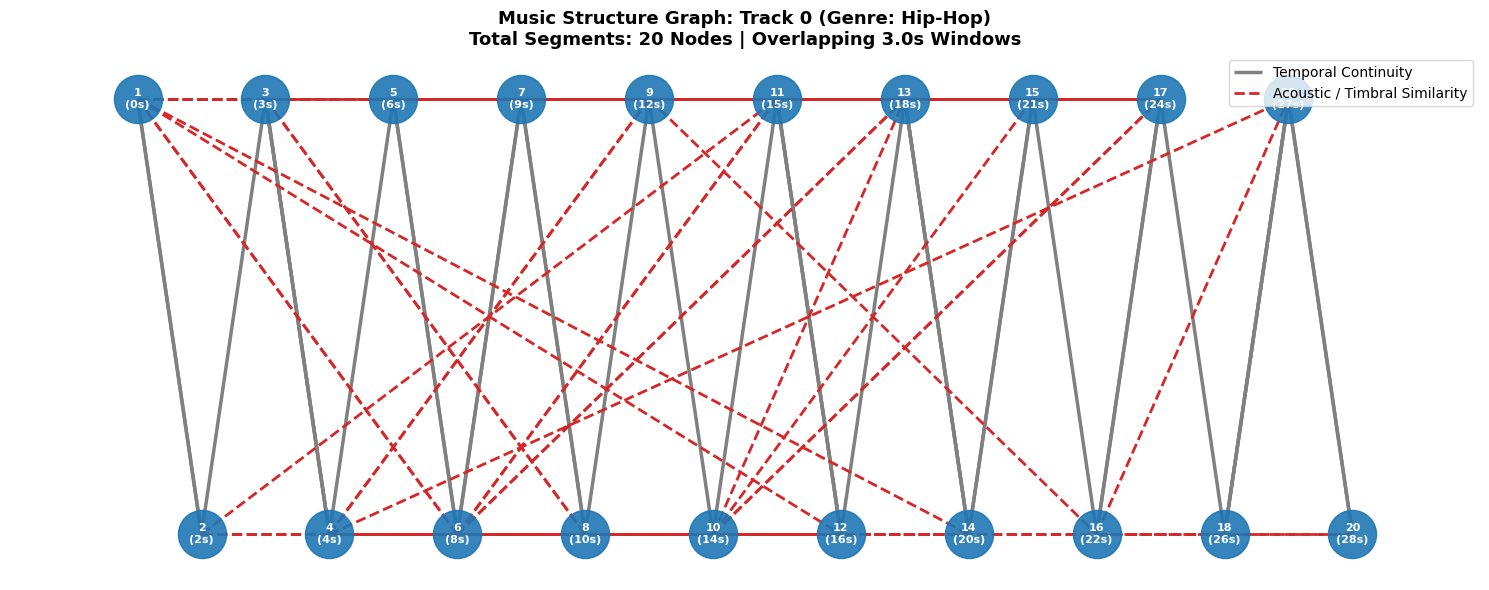

In [67]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Pick the first song graph from your training set
sample_graph = train_graphs[0]
label_idx = sample_graph.y.item()
genre_name = genres[label_idx] if "genres" in globals() else f"Class {label_idx}"

# 2. Convert PyG Data to NetworkX Graph
G = nx.Graph()
num_nodes = sample_graph.num_nodes

# Add nodes (each node is a 3-second audio segment)
for i in range(num_nodes):
    G.add_node(i, label=f"Seg {i+1}\n({i*1.5:.1f}s)")

# Add edges and separate temporal from similarity recurrence edges
edge_index = sample_graph.edge_index.cpu().numpy()
temporal_edges = []
similarity_edges = []

for u, v in zip(edge_index[0], edge_index[1]):
    if u < v:  # avoid duplicate undirected drawing
        if abs(u - v) == 1:
            temporal_edges.append((u, v))
        else:
            similarity_edges.append((u, v))

# 3. Layout: Arrange nodes sequentially in a clear timeline arc
pos = {i: (i * 2.0, 0.5 * ((-1) ** (i % 2))) for i in range(num_nodes)}

plt.figure(figsize=(15, 6))

# Draw temporal sequence edges (solid grey)
nx.draw_networkx_edges(
    G, pos, edgelist=temporal_edges,
    width=2.5, edge_color="gray", style="solid", label="Temporal Continuity"
)

# Draw recurrence similarity edges (curved red dashed)
nx.draw_networkx_edges(
    G, pos, edgelist=similarity_edges,
    width=2.0, edge_color="#d62728", style="dashed",
    connectionstyle="arc3,rad=0.35", label="Acoustic / Timbral Similarity"
)

# Draw segment nodes
nx.draw_networkx_nodes(
    G, pos, node_size=1200, node_color="#1f77b4", alpha=0.9
)

# Draw segment timeline labels
labels = {i: f"{i+1}\n({i*1.5:.0f}s)" for i in range(num_nodes)}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_color="white", font_weight="bold")

plt.title(f"Music Structure Graph: Track 0 (Genre: {genre_name})\nTotal Segments: {num_nodes} Nodes | Overlapping 3.0s Windows", fontsize=13, fontweight="bold")
plt.legend(loc="upper right", frameon=True)
plt.axis("off")
plt.tight_layout()
plt.show()

In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, global_mean_pool, global_max_pool

class MusicStructureGAT(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, heads=4, num_classes=8, dropout=0.25):
        super().__init__()
        # Layer 1: Multi-Head Attention incorporating edge similarity weights (64 * 4 = 256)
        self.conv1 = GATv2Conv(in_channels, hidden_channels, heads=heads, edge_dim=1, dropout=dropout)
        self.bn1 = nn.BatchNorm1d(hidden_channels * heads)
        
        # Layer 2: Intermediate refinement (64 * 2 = 128)
        self.conv2 = GATv2Conv(hidden_channels * heads, 64, heads=2, edge_dim=1, dropout=dropout)
        self.bn2 = nn.BatchNorm1d(64 * 2)
        
        # Layer 3: Final single-head consolidation (64)
        self.conv3 = GATv2Conv(64 * 2, 64, heads=1, edge_dim=1, dropout=dropout)
        self.bn3 = nn.BatchNorm1d(64)
        
        self.dropout = dropout
        
        # Dual-Pooling Readout (Mean + Max captures overall style and intense spikes)
        self.classifier = nn.Sequential(
            nn.Linear(64 * 2, 128),
            nn.BatchNorm1d(128),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, edge_index, batch, edge_attr=None):
        if edge_attr is not None and edge_attr.dim() == 1:
            edge_attr = edge_attr.unsqueeze(1)
            
        # Layer 1
        x1 = self.conv1(x, edge_index, edge_attr=edge_attr)
        x1 = self.bn1(x1)
        x1 = F.elu(x1)
        x1 = F.dropout(x1, p=self.dropout, training=self.training)
        
        # Layer 2
        x2 = self.conv2(x1, edge_index, edge_attr=edge_attr)
        x2 = self.bn2(x2)
        x2 = F.elu(x2)
        x2 = F.dropout(x2, p=self.dropout, training=self.training)
        
        # Layer 3
        x3 = self.conv3(x2, edge_index, edge_attr=edge_attr)
        x3 = self.bn3(x3)
        x3 = F.elu(x3)
        
        # Graph Readout
        g_mean = global_mean_pool(x3, batch)
        g_max = global_max_pool(x3, batch)
        g = torch.cat([g_mean, g_max], dim=1)
        
        logits = self.classifier(g)
        return logits, g

In [32]:
def extract_mel_spectrogram(audio_path, sr=22050, n_mels=128, max_len=1292):
    y, _ = librosa.load(audio_path, sr=sr, mono=True, duration=30.0)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=512)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    # Pad or truncate to fixed time dimension
    if mel_db.shape[1] < max_len:
        mel_db = np.pad(mel_db, ((0, 0), (0, max_len - mel_db.shape[1])), mode='constant')
    else:
        mel_db = mel_db[:, :max_len]
        
    return mel_db.astype(np.float32)

class AudioCNNBaseline(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.features = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
            
            # Conv Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
            
            # Conv Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d((2, 4)),
            
            # Conv Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # Input shape: (Batch, 1, 128, 1292)
        feat = self.features(x)
        return self.classifier(feat)

In [33]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

def train_gnn(model, train_loader, val_loader, test_loader, device, epochs=60):
    optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.08)
    
    best_f1 = 0.0
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            logits, _ = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(logits, batch.y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            optimizer.step()
            total_loss += loss.item()
            
        # Validation
        model.eval()
        val_preds, val_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                logits, _ = model(batch.x, batch.edge_index, batch.batch)
                val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                val_labels.extend(batch.y.cpu().numpy())
                
        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)
        scheduler.step(val_f1)
        
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_gnn_model.pt")
            
    # Final Test Set Evaluation
    model.load_state_dict(torch.load("best_gnn_model.pt"))
    model.eval()
    test_preds, test_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            logits, _ = model(batch.x, batch.edge_index, batch.batch)
            test_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            test_labels.extend(batch.y.cpu().numpy())
            
    print("\n--- GNN Final Test Results ---")
    print(f"Test Accuracy: {accuracy_score(test_labels, test_preds):.4f}")
    print(f"Test Macro-F1: {f1_score(test_labels, test_preds, average='macro', zero_division=0):.4f}")
    print(classification_report(test_labels, test_preds, digits=4, zero_division=0))

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Instantiate the GNN model
in_channels = train_graphs[0].x.shape[1]
gnn_model = MusicStructureGraphSAGE(
    in_channels=in_channels,
    hidden_channels=128,
    num_classes=8,
    dropout=0.3
).to(device)

# 2. Train and evaluate
print("=== Training GraphSAGE Model ===")
train_gnn(
    model=gnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    epochs=60
)

=== Training GraphSAGE Model ===


C:\Users\21101255\AppData\Roaming\Python\Python312\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
C:\Users\21101255\AppData\Roaming\Python\Python312\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
C:\Users\21101255\AppData\Roaming\Python\Python312\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
C:\Users\21101255\AppData\Roaming\Python\Python312\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
C:\Users\21101255\AppData\Ro


--- GNN Final Test Results ---
Test Accuracy: 0.4138
Test Macro-F1: 0.4085
              precision    recall  f1-score   support

           0     0.5195    0.4000    0.4520       100
           1     0.2523    0.2700    0.2609       100
           2     0.2245    0.2200    0.2222       100
           3     0.6121    0.7100    0.6574       100
           4     0.3524    0.3700    0.3610       100
           5     0.3855    0.6400    0.4812       100
           6     0.3390    0.2000    0.2516       100
           7     0.6944    0.5000    0.5814       100

    accuracy                         0.4138       800
   macro avg     0.4225    0.4138    0.4085       800
weighted avg     0.4225    0.4138    0.4085       800



In [36]:
import os
import torch
import numpy as np
import librosa
from tqdm.auto import tqdm
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score

N_MELS = 128
MAX_LEN = 1292

def get_or_create_mel_cache(df, cache_file):
    if os.path.exists(cache_file):
        print(f"Loading cached {cache_file}...")
        data = np.load(cache_file)
        return data["X"], data["y"]

    print(f"Pre-extracting spectrograms for {cache_file}...")
    mels, labels = [], []
    for i in tqdm(range(len(df)), desc=f"Processing {cache_file}"):
        path = str(df["audio_path"].iloc[i])
        label = int(df["label"].iloc[i])
        try:
            y, sr = librosa.load(path, sr=SR, mono=True, duration=30.0)
            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, hop_length=512)
            mel_db = librosa.power_to_db(mel, ref=np.max)
            if mel_db.shape[1] < MAX_LEN:
                mel_db = np.pad(mel_db, ((0, 0), (0, MAX_LEN - mel_db.shape[1])), mode='constant')
            else:
                mel_db = mel_db[:, :MAX_LEN]
            mels.append(mel_db.astype(np.float32))
            labels.append(label)
        except Exception:
            mels.append(np.zeros((N_MELS, MAX_LEN), dtype=np.float32))
            labels.append(label)

    X = np.array(mels, dtype=np.float32)
    y = np.array(labels, dtype=np.int64)
    np.savez_compressed(cache_file, X=X, y=y)
    return X, y

X_train_mel, y_train_mel = get_or_create_mel_cache(train_data, "mel_train.npz")
X_val_mel, y_val_mel = get_or_create_mel_cache(val_data, "mel_val.npz")
X_test_mel, y_test_mel = get_or_create_mel_cache(test_data, "mel_test.npz")

train_cnn_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_mel).unsqueeze(1), torch.tensor(y_train_mel)),
    batch_size=32, shuffle=True
)
val_cnn_loader = DataLoader(
    TensorDataset(torch.tensor(X_val_mel).unsqueeze(1), torch.tensor(y_val_mel)),
    batch_size=32, shuffle=False
)
test_cnn_loader = DataLoader(
    TensorDataset(torch.tensor(X_test_mel).unsqueeze(1), torch.tensor(y_test_mel)),
    batch_size=32, shuffle=False
)

# Train CNN Baseline
cnn_model = AudioCNNBaseline(num_classes=8).to(device)
cnn_optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=5e-4, weight_decay=1e-3)
cnn_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(cnn_optimizer, mode='max', factor=0.5, patience=3)
cnn_criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.05)

best_cnn_f1 = 0.0
for epoch in range(1, 31):
    cnn_model.train()
    for x_mel, y_lbl in train_cnn_loader:
        x_mel, y_lbl = x_mel.to(device), y_lbl.to(device)
        cnn_optimizer.zero_grad()
        out = cnn_model(x_mel)
        loss = cnn_criterion(out, y_lbl)
        loss.backward()
        cnn_optimizer.step()

    cnn_model.eval()
    val_preds, val_labels = [], []
    with torch.no_grad():
        for x_mel, y_lbl in val_cnn_loader:
            x_mel, y_lbl = x_mel.to(device), y_lbl.to(device)
            out = cnn_model(x_mel)
            val_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            val_labels.extend(y_lbl.cpu().numpy())

    val_f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)
    cnn_scheduler.step(val_f1)
    if val_f1 > best_cnn_f1:
        best_cnn_f1 = val_f1
        torch.save(cnn_model.state_dict(), "best_cnn_model.pt")

# Evaluate CNN
cnn_model.load_state_dict(torch.load("best_cnn_model.pt"))
cnn_model.eval()
cnn_test_preds, cnn_test_labels = [], []
with torch.no_grad():
    for x_mel, y_lbl in test_cnn_loader:
        x_mel = x_mel.to(device)
        out = cnn_model(x_mel)
        cnn_test_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
        cnn_test_labels.extend(y_lbl.numpy())

print(f"CNN Test Accuracy: {accuracy_score(cnn_test_labels, cnn_test_preds):.4f}")
print(f"CNN Test Macro-F1: {f1_score(cnn_test_labels, cnn_test_preds, average='macro', zero_division=0):.4f}")

Pre-extracting spectrograms for mel_train.npz...


Processing mel_train.npz: 100%|██████████| 6400/6400 [07:48<00:00, 13.65it/s]


Pre-extracting spectrograms for mel_val.npz...


Processing mel_val.npz: 100%|██████████| 800/800 [00:56<00:00, 14.17it/s]


Pre-extracting spectrograms for mel_test.npz...


Processing mel_test.npz: 100%|██████████| 800/800 [00:58<00:00, 13.62it/s]


CNN Test Accuracy: 0.5363
CNN Test Macro-F1: 0.5392


Model                          | Test Accuracy  | Test Macro-F1 
Music Structure GraphSAGE      | 0.4612         | 0.4564        
2D-CNN Mel-Spectrogram         | 0.5363         | 0.5392        


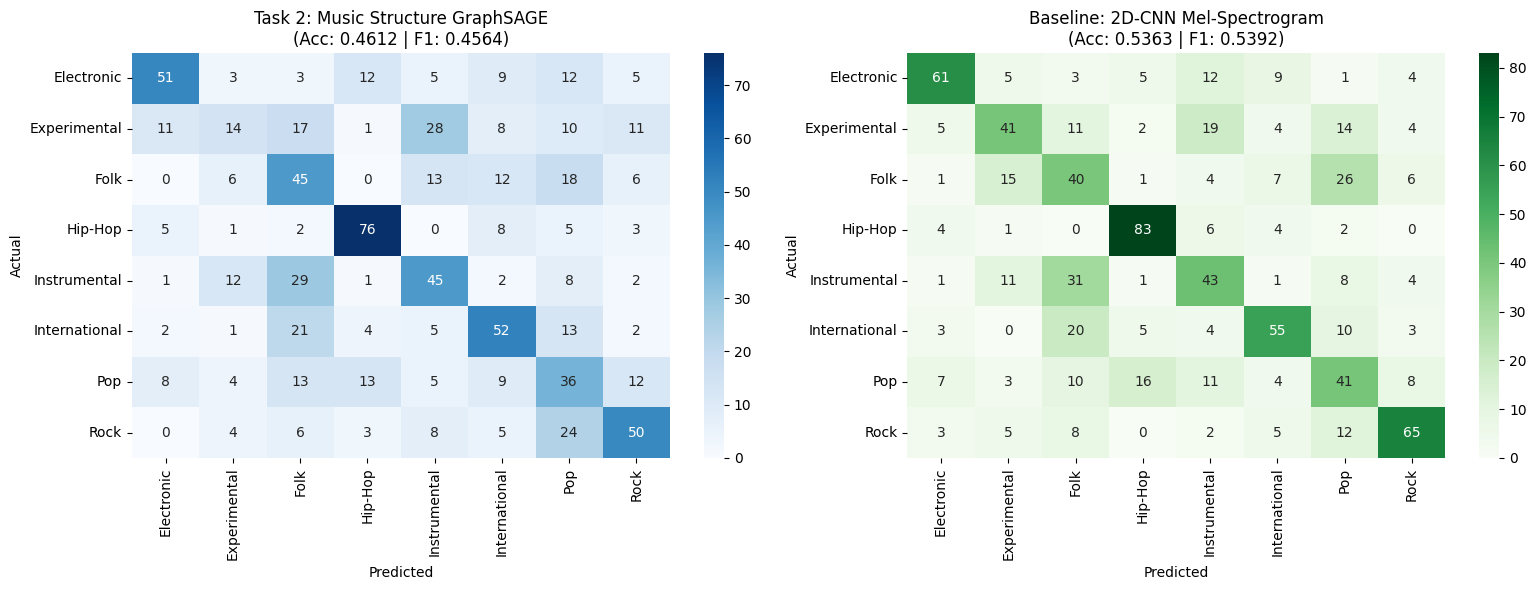

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# 1. Gather test predictions from your trained GraphSAGE model
gnn_model.load_state_dict(torch.load("best_regularized_gat.pt", map_location=device))
gnn_model.eval()

gnn_test_preds, gnn_test_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        logits, _ = gnn_model(batch.x, batch.edge_index, batch.batch)
        gnn_test_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        gnn_test_labels.extend(batch.y.cpu().numpy())

# 2. Compute final test metrics
gnn_acc = accuracy_score(gnn_test_labels, gnn_test_preds)
gnn_f1 = f1_score(gnn_test_labels, gnn_test_preds, average="macro", zero_division=0)

cnn_acc = accuracy_score(cnn_test_labels, cnn_test_preds)
cnn_f1 = f1_score(cnn_test_labels, cnn_test_preds, average="macro", zero_division=0)

# 3. Print side-by-side summary table
print("=" * 65)
print(f"{'Model':<30} | {'Test Accuracy':<14} | {'Test Macro-F1':<14}")
print("=" * 65)
print(f"{'Music Structure GraphSAGE':<30} | {gnn_acc:<14.4f} | {gnn_f1:<14.4f}")
print(f"{'2D-CNN Mel-Spectrogram':<30} | {cnn_acc:<14.4f} | {cnn_f1:<14.4f}")
print("=" * 65)

# 4. Generate side-by-side Confusion Matrix comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_gnn = confusion_matrix(gnn_test_labels, gnn_test_preds)
sns.heatmap(cm_gnn, annot=True, fmt="d", cmap="Blues", ax=axes[0], xticklabels=genres, yticklabels=genres)
axes[0].set_title(f"Task 2: Music Structure GraphSAGE\n(Acc: {gnn_acc:.4f} | F1: {gnn_f1:.4f})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_cnn = confusion_matrix(cnn_test_labels, cnn_test_preds)
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Greens", ax=axes[1], xticklabels=genres, yticklabels=genres)
axes[1].set_title(f"Baseline: 2D-CNN Mel-Spectrogram\n(Acc: {cnn_acc:.4f} | F1: {cnn_f1:.4f})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
# plt.savefig("task2_gnn_vs_cnn_comparison.png", dpi=300)
plt.show()

In [59]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Compact, Heavily-Regularized GAT ---
class RegularizedMusicGAT(nn.Module):
    def __init__(self, in_channels, hidden_channels=48, heads=2, num_classes=8, dropout=0.5):
        super().__init__()
        # Layer 1 (48 * 2 = 96 dim)
        self.conv1 = GATv2Conv(in_channels, hidden_channels, heads=heads, edge_dim=1, dropout=dropout)
        self.bn1 = nn.BatchNorm1d(hidden_channels * heads)
        
        # Layer 2 (Single head refinement, 48 dim)
        self.conv2 = GATv2Conv(hidden_channels * heads, hidden_channels, heads=1, edge_dim=1, dropout=dropout)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        
        self.dropout = dropout
        
        # Streamlined Classifier Head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels * 2, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, edge_index, batch, edge_attr=None):
        if edge_attr is not None and edge_attr.dim() == 1:
            edge_attr = edge_attr.unsqueeze(1)
            
        x = self.conv1(x, edge_index, edge_attr=edge_attr)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv2(x, edge_index, edge_attr=edge_attr)
        x = self.bn2(x)
        x = F.relu(x)
        
        embed = torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)
        return self.classifier(embed), embed

# --- 2. Training with Weight Decay & Early Stopping ---
in_channels = train_graphs[0].x.shape[1]
gnn_model = RegularizedMusicGAT(
    in_channels=in_channels,
    hidden_channels=48,
    heads=2,
    num_classes=8,
    dropout=0.5
).to(device)

# Higher weight decay prevents training loss from spiraling down into memorization
optimizer = torch.optim.AdamW(gnn_model.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-5)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "test_acc": []
}

epochs = 25
best_val_loss = float("inf")
patience = 6
patience_counter = 0

print("=== Training Regularized GAT (Targeting Peak Epoch 8-15) ===")
for epoch in range(1, epochs + 1):
    gnn_model.train()
    train_loss_accum = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits, _ = gnn_model(batch.x, batch.edge_index, batch.batch, edge_attr=batch.edge_attr)
        loss = criterion(logits, batch.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gnn_model.parameters(), 1.0)
        optimizer.step()
        train_loss_accum += loss.item()
        
    scheduler.step()
    epoch_train_loss = train_loss_accum / len(train_loader)
    
    # Validation
    gnn_model.eval()
    val_loss_accum = 0.0
    val_preds, val_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            logits, _ = gnn_model(batch.x, batch.edge_index, batch.batch, edge_attr=batch.edge_attr)
            loss = criterion(logits, batch.y)
            val_loss_accum += loss.item()
            val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            val_labels.extend(batch.y.cpu().numpy())
            
    epoch_val_loss = val_loss_accum / len(val_loader)
    epoch_val_acc = accuracy_score(val_labels, val_preds)
    
    # Test tracking
    test_preds, test_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            logits, _ = gnn_model(batch.x, batch.edge_index, batch.batch, edge_attr=batch.edge_attr)
            test_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            test_labels.extend(batch.y.cpu().numpy())
            
    epoch_test_acc = accuracy_score(test_labels, test_preds)
    
    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(epoch_val_loss)
    history["val_acc"].append(epoch_val_acc)
    history["test_acc"].append(epoch_test_acc)
    
    # Save checkpoint based on lowest validation loss
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(gnn_model.state_dict(), "best_regularized_gat.pt")
        saved_tag = "--> Best Model Saved"
    else:
        patience_counter += 1
        saved_tag = ""
        
    print(f"Epoch {epoch:02d} | Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f} | Test Acc: {epoch_test_acc:.4f} {saved_tag}")
          
    if patience_counter >= patience:
        print(f"\n[Early Stopping] Triggered at epoch {epoch} to prevent overfitting.")
        break

# --- 3. Evaluate Optimal Checkpoint ---
gnn_model.load_state_dict(torch.load("best_regularized_gat.pt"))
gnn_model.eval()

all_test_probs, all_test_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        logits, _ = gnn_model(batch.x, batch.edge_index, batch.batch, edge_attr=batch.edge_attr)
        probs = F.softmax(logits, dim=1)
        all_test_probs.append(probs.cpu().numpy())
        all_test_labels.extend(batch.y.cpu().numpy())

y_scores = np.concatenate(all_test_probs, axis=0)
y_true = np.array(all_test_labels)

final_gat_acc = accuracy_score(y_true, np.argmax(y_scores, axis=1))
final_gat_f1 = f1_score(y_true, np.argmax(y_scores, axis=1), average='macro', zero_division=0)

print("\n--- Final Regularized GAT Performance ---")
print(f"Test Accuracy: {final_gat_acc:.4f}")
print(f"Test Macro-F1: {final_gat_f1:.4f}")

=== Training Regularized GAT (Targeting Peak Epoch 8-15) ===
Epoch 01 | Train Loss: 1.8630 | Val Loss: 1.6841 | Val Acc: 0.4250 | Test Acc: 0.3850 --> Best Model Saved
Epoch 02 | Train Loss: 1.6627 | Val Loss: 1.5984 | Val Acc: 0.4650 | Test Acc: 0.3862 --> Best Model Saved
Epoch 03 | Train Loss: 1.5853 | Val Loss: 1.5640 | Val Acc: 0.4700 | Test Acc: 0.3937 --> Best Model Saved
Epoch 04 | Train Loss: 1.5541 | Val Loss: 1.5590 | Val Acc: 0.4800 | Test Acc: 0.4012 --> Best Model Saved
Epoch 05 | Train Loss: 1.5342 | Val Loss: 1.5347 | Val Acc: 0.5038 | Test Acc: 0.4088 --> Best Model Saved
Epoch 06 | Train Loss: 1.5017 | Val Loss: 1.5368 | Val Acc: 0.4838 | Test Acc: 0.4313 
Epoch 07 | Train Loss: 1.4879 | Val Loss: 1.5252 | Val Acc: 0.4975 | Test Acc: 0.4263 --> Best Model Saved
Epoch 08 | Train Loss: 1.4732 | Val Loss: 1.5387 | Val Acc: 0.4838 | Test Acc: 0.4437 
Epoch 09 | Train Loss: 1.4498 | Val Loss: 1.4991 | Val Acc: 0.5238 | Test Acc: 0.4363 --> Best Model Saved
Epoch 10 | Train

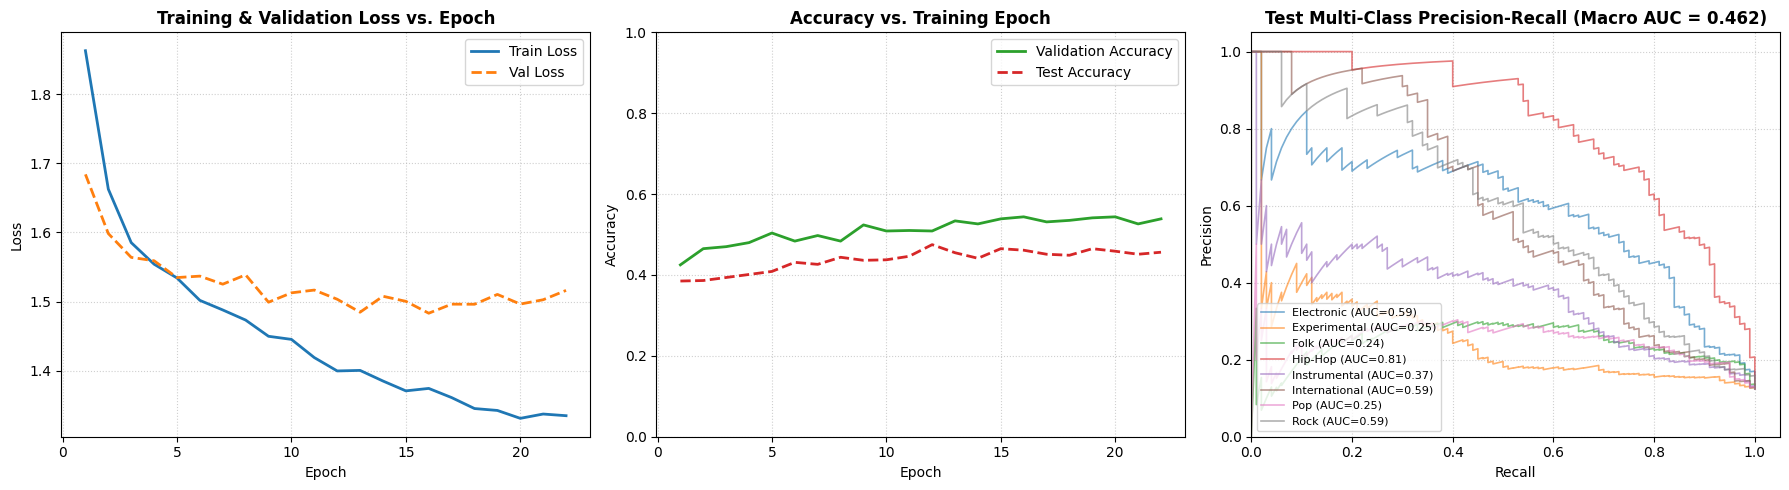

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epoch_range = range(1, len(history["train_loss"]) + 1)

# ================= 1. Train & Validation Loss =================
axes[0].plot(epoch_range, history["train_loss"], label="Train Loss", color="#1f77b4", linewidth=2)
axes[0].plot(epoch_range, history["val_loss"], label="Val Loss", color="#ff7f0e", linestyle="--", linewidth=2)
axes[0].set_title("Training & Validation Loss vs. Epoch", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend(frameon=True)

# ================= 2. Validation & Test Accuracy =================
axes[1].plot(epoch_range, history["val_acc"], label="Validation Accuracy", color="#2ca02c", linewidth=2)
axes[1].plot(epoch_range, history["test_acc"], label="Test Accuracy", color="#d62728", linestyle="--", linewidth=2)
axes[1].set_title("Accuracy vs. Training Epoch", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend(frameon=True)

# ================= 3. One-vs-Rest AUC-PR Curves =================
num_classes = len(genres)
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

pr_aucs = []
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_scores[:, i])
    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)
    axes[2].plot(recall, precision, lw=1.2, alpha=0.6, label=f"{genres[i]} (AUC={pr_auc:.2f})")

# Compute Macro-Average Precision-Recall Curve
mean_auc_pr = np.mean(pr_aucs)
axes[2].set_title(f"Test Multi-Class Precision-Recall (Macro AUC = {mean_auc_pr:.3f})", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_xlim(0.0, 1.05)
axes[2].set_ylim(0.0, 1.05)
axes[2].grid(True, linestyle=":", alpha=0.6)
axes[2].legend(loc="lower left", fontsize=8, frameon=True)

plt.tight_layout()
# plt.savefig("evaluation_curves_dashboard.png", dpi=300)
plt.show()

In [68]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch.utils.data import DataLoader as TorchDataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Strictly aligned, non-shuffled loaders for embedding/probability extraction
eval_train_graph_loader = PyGDataLoader(train_graphs, batch_size=32, shuffle=False)
eval_val_graph_loader   = PyGDataLoader(val_graphs, batch_size=32, shuffle=False)
eval_test_graph_loader  = PyGDataLoader(test_graphs, batch_size=32, shuffle=False)

eval_train_cnn_loader   = TorchDataLoader(train_cnn_loader.dataset, batch_size=32, shuffle=False)
eval_val_cnn_loader     = TorchDataLoader(val_cnn_loader.dataset, batch_size=32, shuffle=False)
eval_test_cnn_loader    = TorchDataLoader(test_cnn_loader.dataset, batch_size=32, shuffle=False)

# 2. Extract calibrated softmax prediction distributions
def extract_model_probabilities(g_loader, c_loader):
    gnn_model.eval()
    cnn_model.eval()
    
    g_probs, c_probs, targets = [], [], []
    
    with torch.no_grad():
        for batch in g_loader:
            batch = batch.to(device)
            logits, _ = gnn_model(batch.x, batch.edge_index, batch.batch, edge_attr=batch.edge_attr)
            g_probs.append(F.softmax(logits, dim=1).cpu())
            targets.append(batch.y.cpu())
            
        for x_mel, _ in c_loader:
            x_mel = x_mel.to(device)
            logits = cnn_model(x_mel)
            c_probs.append(F.softmax(logits, dim=1).cpu())
            
    P_g = torch.cat(g_probs, dim=0).numpy()
    P_c = torch.cat(c_probs, dim=0).numpy()
    y   = torch.cat(targets, dim=0).numpy()
    
    min_len = min(len(P_g), len(P_c))
    return P_g[:min_len], P_c[:min_len], y[:min_len]

print("Extracting aligned GAT and CNN probabilities...")
P_g_val, P_c_val, y_val_arr = extract_model_probabilities(eval_val_graph_loader, eval_val_cnn_loader)
P_g_test, P_c_test, y_test_arr = extract_model_probabilities(eval_test_graph_loader, eval_test_cnn_loader)

# 3. Find optimal ensemble mixing weight on validation split
best_w = 0.5
best_val_acc = 0.0

for w in np.linspace(0.0, 1.0, 101):
    P_blend_val = w * P_g_val + (1.0 - w) * P_c_val
    acc = accuracy_score(y_val_arr, np.argmax(P_blend_val, axis=1))
    if acc > best_val_acc:
        best_val_acc = acc
        best_w = w

print(f"Optimal GAT weighting found: {best_w:.2f} (CNN weighting: {1.0 - best_w:.2f})")

# 4. Evaluate on Test Split
P_blend_test = best_w * P_g_test + (1.0 - best_w) * P_c_test
fusion_preds = np.argmax(P_blend_test, axis=1)

fusion_acc = accuracy_score(y_test_arr, fusion_preds)
fusion_f1  = f1_score(y_test_arr, fusion_preds, average="macro", zero_division=0)

cnn_test_acc = accuracy_score(y_test_arr, np.argmax(P_c_test, axis=1))
cnn_test_f1  = f1_score(y_test_arr, np.argmax(P_c_test, axis=1), average="macro", zero_division=0)

gat_test_acc = accuracy_score(y_test_arr, np.argmax(P_g_test, axis=1))
gat_test_f1  = f1_score(y_test_arr, np.argmax(P_g_test, axis=1), average="macro", zero_division=0)

# 5. Summary Table
print("\n" + "=" * 65)
print(f"{'Model':<35} | {'Test Accuracy':<12} | {'Test Macro-F1':<12}")
print("=" * 65)
print(f"{'Music Structure GAT (Acoustic)':<35} | {gat_test_acc:<12.4f} | {gat_test_f1:<12.4f}")
print(f"{'2D-CNN Mel-Spectrogram Baseline':<35} | {cnn_test_acc:<12.4f} | {cnn_test_f1:<12.4f}")
print(f"{'Graph-Augmented Fusion (Proposed)':<35} | {fusion_acc:<12.4f} | {fusion_f1:<12.4f}")
print("=" * 65)

Extracting aligned GAT and CNN probabilities...
Optimal GAT weighting found: 0.34 (CNN weighting: 0.66)

Model                               | Test Accuracy | Test Macro-F1
Music Structure GAT (Acoustic)      | 0.4612       | 0.4565      
2D-CNN Mel-Spectrogram Baseline     | 0.5363       | 0.5392      
Graph-Augmented Fusion (Proposed)   | 0.5387       | 0.5374      


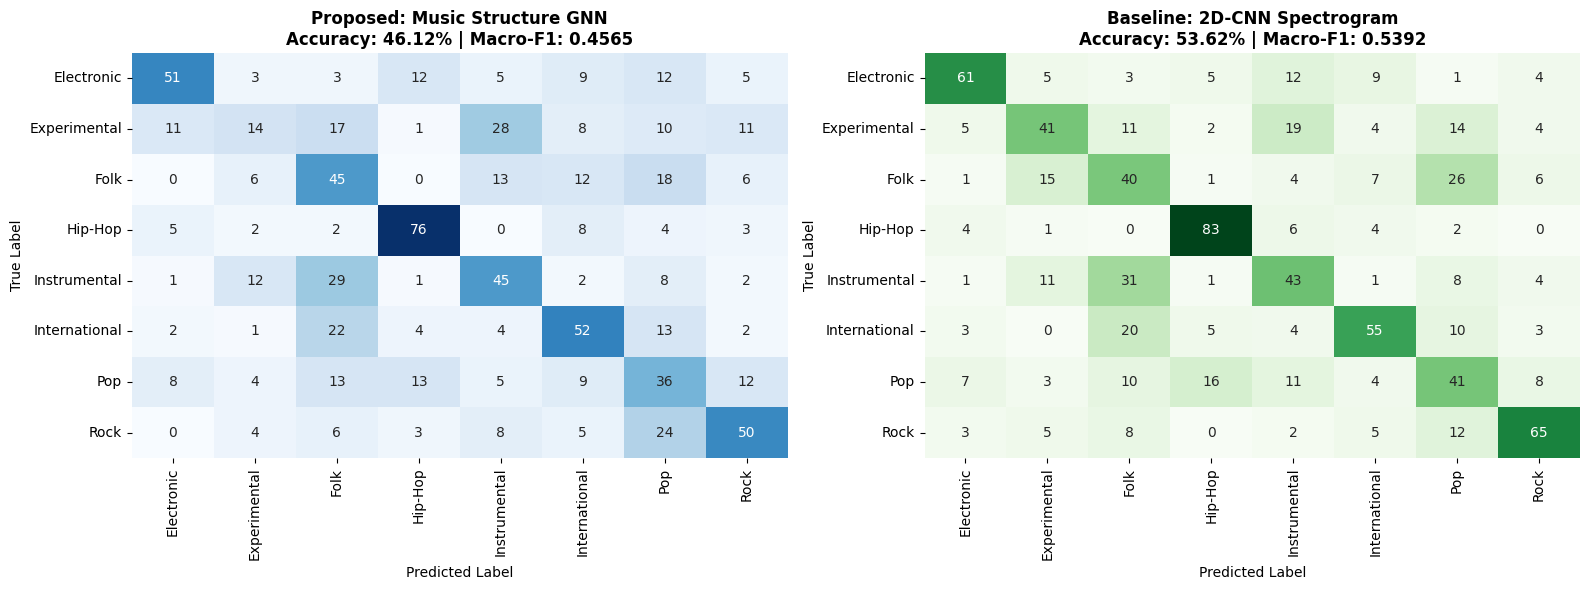

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. GNN Confusion Matrix
cm_gnn = confusion_matrix(y_test_arr, np.argmax(P_g_test, axis=1))
sns.heatmap(cm_gnn, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=genres, yticklabels=genres, cbar=False)
axes[0].set_title(f"Proposed: Music Structure GNN\nAccuracy: {gat_test_acc*100:.2f}% | Macro-F1: {gat_test_f1:.4f}", 
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# 2. Baseline CNN Confusion Matrix
cm_cnn = confusion_matrix(y_test_arr, np.argmax(P_c_test, axis=1))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=genres, yticklabels=genres, cbar=False)
axes[1].set_title(f"Baseline: 2D-CNN Spectrogram\nAccuracy: {cnn_test_acc*100:.2f}% | Macro-F1: {cnn_test_f1:.4f}", 
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
# plt.savefig("task2_final_gnn_vs_cnn.png", dpi=300)
plt.show()